# Homework 1 - Implementing Perceptron & Logistic Regression

## Preview

This notebook develops and compares two linear binary classifiers,
a Perceptron and Logistic Regression, using the UCI Forest Cover
Type dataset. The original multiclass problem is converted into a
binary classification task by retaining Cover Types 1 and 2. Cover
Type 1 is encoded as class 0, while Cover Type 2 is encoded as class
1 and is therefore treated as the positive class.

After filtering, the dataset contains 495,141 observations and 54
features. The data are divided into stratified training and testing
sets using an 80/20 split with a fixed random seed. Feature
standardization is fitted only on the training set and then applied
to both sets, preventing information from the test set from entering
the preprocessing stage.

Both classifiers are implemented from scratch with NumPy. The
Perceptron uses online mistake-driven updates, while Logistic
Regression uses the sigmoid function, binary cross-entropy loss, and
mini-batch gradient descent. The full 54-feature models are evaluated
on the same test set using accuracy, precision, recall, F1-score, and
confusion matrices. Test-set BCE is additionally reported for
Logistic Regression because it produces predicted probabilities.

Since a 54-dimensional decision boundary cannot be displayed
directly in two dimensions, separate visualization models are trained
using standardized Elevation and Horizontal Distance to Roadways.
These two-feature models are used only for decision-boundary plots;
the final performance comparison is based on the full 54-feature
models. The notebook also examines how BCE changes as a function of
predicted probability.

## Data preparation

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 42

### Loading Data

In [16]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
covertype = fetch_ucirepo(id=31) 
  
# data (as pandas dataframes) 
X_all = covertype.data.features 
y_all = covertype.data.targets 

In [22]:
print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
print("\nClass counts:")
print(y_all.value_counts().sort_index())

X_all shape: (581012, 54)
y_all shape: (581012, 1)

Class counts:
Cover_Type
1             211840
2             283301
3              35754
4               2747
5               9493
6              17367
7              20510
Name: count, dtype: int64


### Selecting Type 1 and 2 as the types to study in this homework

In [26]:
mask = y_all['Cover_Type'].isin([1, 2])

X = X_all.loc[mask].reset_index(drop=True).copy()
y = y_all.loc[mask, 'Cover_Type'].map({1:0, 2: 1}).reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nClass counts:")
print(y.value_counts().sort_index())

X shape: (495141, 54)
y shape: (495141,)

Class counts:
Cover_Type
0    211840
1    283301
Name: count, dtype: int64


### Spliting data and scaling data

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_STATE, stratify=y)

print(f"Training shapes of X and y: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes of X and y: {X_test.shape}, {y_test.shape}")

Training shapes of X and y: (396112, 54), (396112,)
Testing shapes of X and y: (99029, 54), (99029,)


In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

Training shape: (396112, 54)
Testing shape: (99029, 54)


## Perceptron

In [52]:
class Perceptron:
    def __init__(self, learning_rate=0.01, max_epochs=10, shuffle=True, random_state=42):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int64).reshape(-1)

        n_samples, n_features = X.shape

        # initialize weights and bias
        self.weights_ = np.zeros(n_features)
        self.bias_ = 0.0
        self.n_features_in_ = n_features
        self.mistakes_per_epoch_ = []

        rng = np.random.default_rng(self.random_state)
        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            if self.shuffle:
                rng.shuffle(indices)

            mistakes = 0

            for i in indices:
                score = np.dot(X[i], self.weights_) + self.bias_
                prediction = int(score >= 0.0)
                error = y[i] - prediction

                if error != 0:
                    self.weights_ = self.weights_ + self.learning_rate * error * X[i]
                    self.bias_ = self.bias_ + self.learning_rate * error

                    mistakes += 1

            self.mistakes_per_epoch_.append(mistakes)

            if mistakes == 0:
                break
        self.n_epochs_run_ = len(self.mistakes_per_epoch_)

        return self


    def decision_function(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.weights_ + self.bias_

    def predict(self, X):
        scores = self.decision_function(X)
        return (scores >= 0.0).astype(np.int64)


In [53]:
perceptron = Perceptron(learning_rate=0.01, max_epochs=10, shuffle=True, random_state=RANDOM_STATE)
perceptron.fit(X_train_scaled, y_train)
y_pred_perceptron = perceptron.predict(X_test_scaled)

print("Weights shape:", perceptron.weights_.shape)
print("Epochs run:", perceptron.n_epochs_run_)
print(
    "Mistakes per epoch:",
    perceptron.mistakes_per_epoch_
)
print(
    "Predicted class counts:",
    np.bincount(y_pred_perceptron, minlength=2)
)

Weights shape: (54,)
Epochs run: 10
Mistakes per epoch: [123193, 123363, 123442, 123432, 123471, 123220, 123434, 123329, 123439, 123230]
Predicted class counts: [35355 63674]


In [64]:
tp = sum((y_test == 1) & (y_pred_perceptron == 1))
tn = sum((y_test == 0) & (y_pred_perceptron == 0))
fp = sum((y_test == 0) & (y_pred_perceptron == 1))
fn = sum((y_test == 1) & (y_pred_perceptron == 0))

assert tp + tn + fp + fn == len(y_test)

accuracy = (tp + tn) / len(y_test)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * ((precision * recall) / (precision + recall))
perceptron_results = {'Model': 'Perceptron', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}

confusion_table = pd.DataFrame([[tn, fp], 
                               [fn, tp]],
                               index=['Actual 0', 'Actual 1'],
                               columns=['Predicted 0', 'Predicted 1'])
display(confusion_table.style)
display(pd.DataFrame([perceptron_results]).round(4).style)

,Predicted 0,Predicted 1
Actual 0,23488,18880
Actual 1,11867,44794


,Model,Accuracy,Precision,Recall,F1
0,Perceptron,0.689500,0.703500,0.790600,0.744500


In [66]:
FEATURES_2D = [
    "Elevation",
    "Horizontal_Distance_To_Roadways"
]

feature_positions = [
    X_train.columns.get_loc(feature_name)
    for feature_name in FEATURES_2D
]

X_train_2d_scaled = X_train_scaled[:, feature_positions]
X_test_2d_scaled = X_test_scaled[:, feature_positions]

print("Selected features:", FEATURES_2D)
print("Training shape:", X_train_2d_scaled.shape)
print("Testing shape:", X_test_2d_scaled.shape)

Selected features: ['Elevation', 'Horizontal_Distance_To_Roadways']
Training shape: (396112, 2)
Testing shape: (99029, 2)


In [67]:
perceptron_2d = Perceptron(
    learning_rate=0.01,
    max_epochs=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

perceptron_2d.fit(X_train_2d_scaled, y_train)

y_pred_perceptron_2d = perceptron_2d.predict(
    X_test_2d_scaled
)

accuracy_perceptron_2d = np.mean(
    np.asarray(y_test) == y_pred_perceptron_2d
)

print("2D weights:", perceptron_2d.weights_)
print("2D bias:", perceptron_2d.bias_)
print(
    "Mistakes per epoch:",
    perceptron_2d.mistakes_per_epoch_
)
print(
    f"2D visualization-model accuracy: "
    f"{accuracy_perceptron_2d:.4f}"
)

2D weights: [-0.02224116 -0.00481269]
2D bias: -3.469446951953614e-18
Mistakes per epoch: [138879, 139437, 138898, 139626, 138879, 139190, 139689, 139002, 139124, 138720]
2D visualization-model accuracy: 0.7082


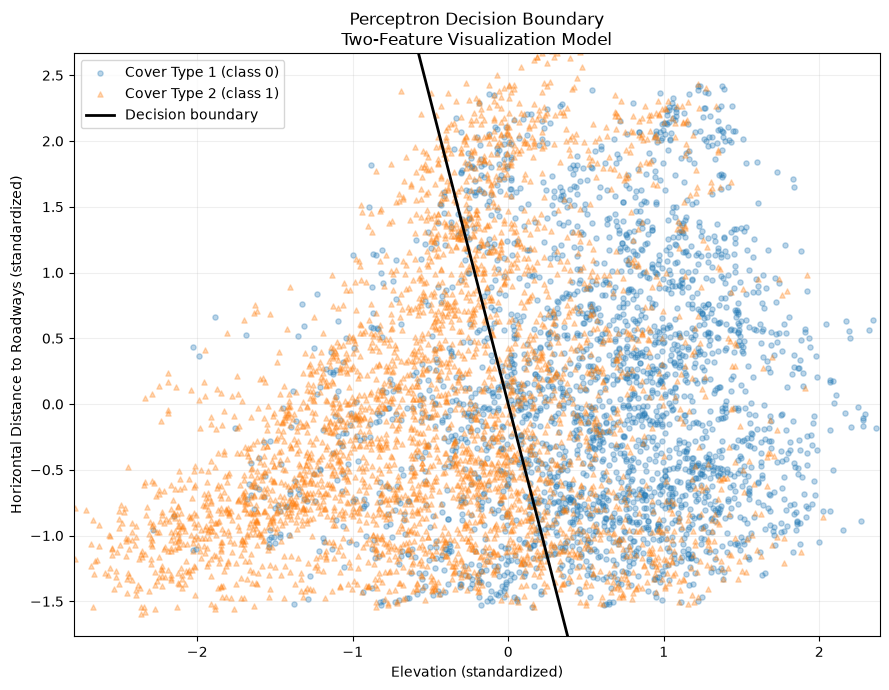

In [68]:
y_test_array = np.asarray(y_test)

plot_rng = np.random.default_rng(RANDOM_STATE)
n_plot = min(6000, len(X_test_2d_scaled))

sample_indices = plot_rng.choice(
    len(X_test_2d_scaled),
    size=n_plot,
    replace=False
)

X_plot = X_test_2d_scaled[sample_indices]
y_plot = y_test_array[sample_indices]

fig, ax = plt.subplots(figsize=(9, 7))

class_styles = {
    0: {
        "label": "Cover Type 1 (class 0)",
        "color": "tab:blue",
        "marker": "o"
    },
    1: {
        "label": "Cover Type 2 (class 1)",
        "color": "tab:orange",
        "marker": "^"
    }
}

for class_label, style in class_styles.items():
    class_mask = y_plot == class_label

    ax.scatter(
        X_plot[class_mask, 0],
        X_plot[class_mask, 1],
        s=14,
        alpha=0.30,
        c=style["color"],
        marker=style["marker"],
        label=style["label"]
    )

# Use central 99% of values so extreme outliers do not compress the plot
x1_min, x1_max = np.percentile(
    X_test_2d_scaled[:, 0],
    [0.5, 99.5]
)
x2_min, x2_max = np.percentile(
    X_test_2d_scaled[:, 1],
    [0.5, 99.5]
)

x1_min -= 0.25
x1_max += 0.25
x2_min -= 0.25
x2_max += 0.25

w1, w2 = perceptron_2d.weights_
b = perceptron_2d.bias_

if not np.isclose(w2, 0.0):
    boundary_x1 = np.linspace(x1_min, x1_max, 300)
    boundary_x2 = -(w1 * boundary_x1 + b) / w2

    ax.plot(
        boundary_x1,
        boundary_x2,
        color="black",
        linewidth=2,
        label="Decision boundary"
    )

elif not np.isclose(w1, 0.0):
    boundary_x1 = -b / w1

    ax.axvline(
        boundary_x1,
        color="black",
        linewidth=2,
        label="Decision boundary"
    )

else:
    print("No boundary: both learned weights are zero.")

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)

ax.set_xlabel("Elevation (standardized)")
ax.set_ylabel(
    "Horizontal Distance to Roadways (standardized)"
)
ax.set_title(
    "Perceptron Decision Boundary\n"
    "Two-Feature Visualization Model"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Logistic Regression

In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, max_epochs=50, batch_size=10000, shuffle=True, random_state=42):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.random_state = random_state

    @staticmethod
    def _sigmoid(logits):
        logits = np.asarray(logits, dtype=np.float64)
        probabilities = 1 / (1 + np.exp(-logits))
        return probabilities

    @staticmethod
    def _binary_cross_entropy(y, probabilities):
        return -np.mean(
            y * np.log(probabilities)
            + (1 - y) * np.log(1 - probabilities)
        )

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).reshape(-1)

        n_samples, n_features = X.shape
        if self.batch_size is None:
            batch_size = n_samples
        else:
            batch_size = min(self.batch_size, n_samples)

        self.weights_ = np.zeros(n_features)
        self.bias_ = 0.0
        self.n_features_in_ = n_features
        self.loss_history_ = []

        rng = np.random.default_rng(self.random_state)

        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            if self.shuffle:
                rng.shuffle(indices)

            for start in range(0, n_samples, batch_size):
                batch_indices = indices[
                    start:start + batch_size
                ]

                X_batch = X[batch_indices]
                y_batch = y[batch_indices]

                # 1. Linear scores
                logits = (
                    X_batch @ self.weights_
                    + self.bias_
                )

                # 2. Predicted probabilities
                probabilities = self._sigmoid(
                    logits
                )

                # 3. Prediction errors
                errors = probabilities - y_batch

                # 4. Gradients
                gradient_weights = (
                    X_batch.T @ errors
                    / len(y_batch)
                )

                gradient_bias = errors.mean()

                # 5. Gradient-descent update
                self.weights_ -= (
                    self.learning_rate
                    * gradient_weights
                )

                self.bias_ -= (
                    self.learning_rate
                    * gradient_bias
                )

            # Exact training BCE after this epoch
            training_logits = (
                X @ self.weights_
                + self.bias_
            )

            training_probabilities = self._sigmoid(
                training_logits
            )

            training_loss = self._binary_cross_entropy(
                y,
                training_probabilities
            )

            self.loss_history_.append(training_loss)
            
        self.n_epochs_run_ = len(
            self.loss_history_
        )

        return self

    def decision_function(self, X):
        if not hasattr(self, "weights_"):
            raise RuntimeError(
                "Call fit() before prediction."
            )

        X = np.asarray(X, dtype=np.float64)

        if (
            X.ndim != 2
            or X.shape[1] != self.n_features_in_
        ):
            raise ValueError(
                f"X must have shape "
                f"(n_samples, {self.n_features_in_})."
            )

        return X @ self.weights_ + self.bias_

    def predict_proba(self, X):
        """
        Return P(y=1 | x).
        """
        logits = self.decision_function(X)
        return self._sigmoid(logits)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)

        return (
            probabilities >= threshold
        ).astype(np.int64)

In [79]:
logistic_54 = LogisticRegression(
    learning_rate=0.1,
    max_epochs=50,
    batch_size=8192,
    shuffle=True,
    random_state=RANDOM_STATE
)

logistic_54.fit(
    X_train_scaled,
    y_train
)

test_prob_logistic = (
    logistic_54.predict_proba(
        X_test_scaled
    )
)

y_pred_logistic = logistic_54.predict(
    X_test_scaled
)

print(
    "Weights shape:",
    logistic_54.weights_.shape
)
print(
    "Epochs run:",
    logistic_54.n_epochs_run_
)
print(
    "First training BCE:",
    logistic_54.loss_history_[0]
)
print(
    "Final training BCE:",
    logistic_54.loss_history_[-1]
)
print(
    "Test-probability range:",
    test_prob_logistic.min(),
    test_prob_logistic.max()
)
print(
    "Predicted class counts:",
    np.bincount(
        y_pred_logistic,
        minlength=2
    )
)

Weights shape: (54,)
Epochs run: 50
First training BCE: 0.5187251200098113
Final training BCE: 0.47589669038136334
Test-probability range: 0.0025529525215244064 0.9999613577195907
Predicted class counts: [40431 58598]


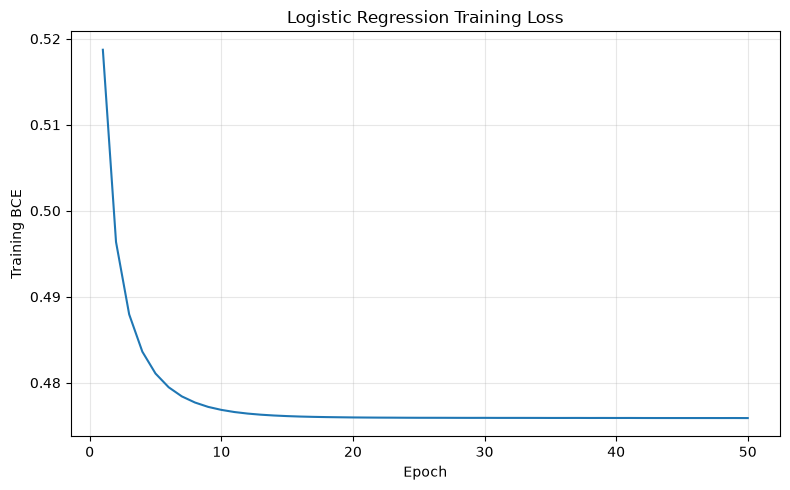

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        logistic_54.n_epochs_run_ + 1
    ),
    logistic_54.loss_history_
)

plt.xlabel("Epoch")
plt.ylabel("Training BCE")
plt.title(
    "Logistic Regression Training Loss"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
y_test_array = np.asarray(
    y_test,
    dtype=np.int64
)

tp_logistic = int(np.sum(
    (y_test_array == 1)
    & (y_pred_logistic == 1)
))

tn_logistic = int(np.sum(
    (y_test_array == 0)
    & (y_pred_logistic == 0)
))

fp_logistic = int(np.sum(
    (y_test_array == 0)
    & (y_pred_logistic == 1)
))

fn_logistic = int(np.sum(
    (y_test_array == 1)
    & (y_pred_logistic == 0)
))

assert (
    tp_logistic
    + tn_logistic
    + fp_logistic
    + fn_logistic
    == len(y_test_array)
)

accuracy_logistic = (
    tp_logistic + tn_logistic
) / len(y_test_array)

precision_logistic = (
    tp_logistic
    / (tp_logistic + fp_logistic)
)

recall_logistic = (
    tp_logistic
    / (tp_logistic + fn_logistic)
)

f1_logistic = (
    2
    * precision_logistic
    * recall_logistic
    / (precision_logistic + recall_logistic)
)

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_logistic,
    "Precision": precision_logistic,
    "Recall": recall_logistic,
    "F1": f1_logistic
}

In [82]:
logistic_confusion_table = pd.DataFrame(
    [
        [tn_logistic, fp_logistic],
        [fn_logistic, tp_logistic]
    ],
    index=[
        "Actual 0",
        "Actual 1"
    ],
    columns=[
        "Predicted 0",
        "Predicted 1"
    ]
)

display(logistic_confusion_table.style)

display(
    pd.DataFrame([logistic_results])
    .round(4)
    .style
)

,Predicted 0,Predicted 1
Actual 0,30232,12136
Actual 1,10199,46462


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.774500,0.792900,0.820000,0.806200


In [83]:
test_bce_logistic = (
    logistic_54._binary_cross_entropy(
        y_test_array,
        test_prob_logistic
    )
)

print(
    f"Logistic Regression test BCE: "
    f"{test_bce_logistic:.6f}"
)

Logistic Regression test BCE: 0.478160


In [84]:
logistic_2d = LogisticRegression(
    learning_rate=0.1,
    max_epochs=50,
    batch_size=8192,
    shuffle=True,
    random_state=RANDOM_STATE
)

logistic_2d.fit(
    X_train_2d_scaled,
    y_train
)

y_pred_logistic_2d = logistic_2d.predict(
    X_test_2d_scaled
)

accuracy_logistic_2d = np.mean(
    y_test_array
    == y_pred_logistic_2d
)

print("2D weights:", logistic_2d.weights_)
print("2D bias:", logistic_2d.bias_)

print(
    "First training BCE:",
    logistic_2d.loss_history_[0]
)

print(
    "Final training BCE:",
    logistic_2d.loss_history_[-1]
)

print(
    f"2D visualization-model accuracy: "
    f"{accuracy_logistic_2d:.4f}"
)

2D weights: [-1.43001189  0.10288314]
2D bias: 0.4367656613748622
First training BCE: 0.5615806535436274
Final training BCE: 0.5312099342819556
2D visualization-model accuracy: 0.7429


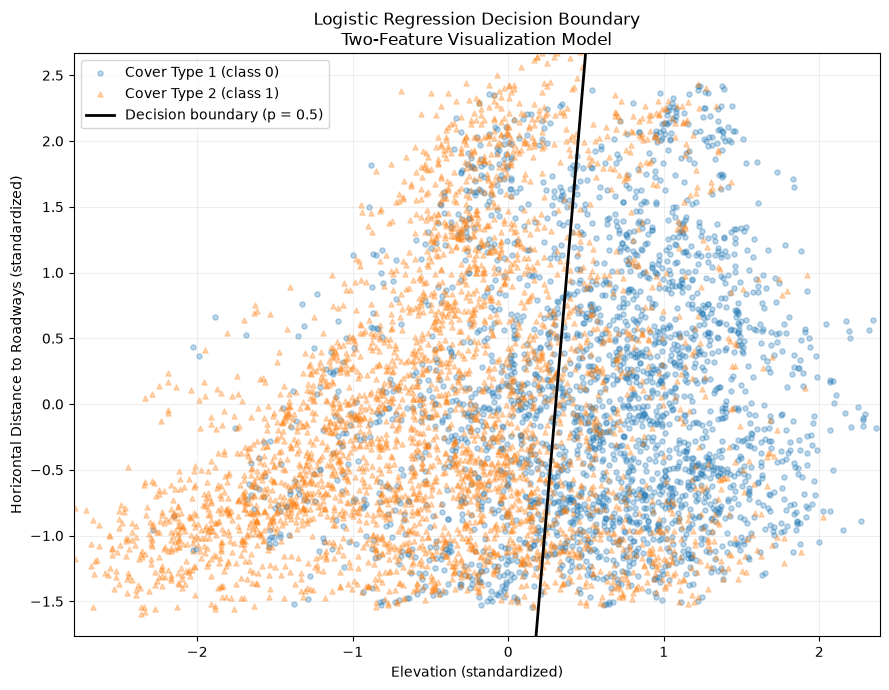

In [85]:
fig, ax = plt.subplots(figsize=(9, 7))

for class_label, style in class_styles.items():
    class_mask = y_plot == class_label

    ax.scatter(
        X_plot[class_mask, 0],
        X_plot[class_mask, 1],
        s=14,
        alpha=0.30,
        c=style["color"],
        marker=style["marker"],
        label=style["label"]
    )

w1, w2 = logistic_2d.weights_
b = logistic_2d.bias_

if not np.isclose(w2, 0.0):
    boundary_x1 = np.linspace(
        x1_min,
        x1_max,
        300
    )

    boundary_x2 = -(
        w1 * boundary_x1 + b
    ) / w2

    ax.plot(
        boundary_x1,
        boundary_x2,
        color="black",
        linewidth=2,
        label="Decision boundary (p = 0.5)"
    )

elif not np.isclose(w1, 0.0):
    ax.axvline(
        -b / w1,
        color="black",
        linewidth=2,
        label="Decision boundary (p = 0.5)"
    )

else:
    print(
        "No boundary: both weights are zero."
    )

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)

ax.set_xlabel("Elevation (standardized)")
ax.set_ylabel(
    "Horizontal Distance to Roadways "
    "(standardized)"
)

ax.set_title(
    "Logistic Regression Decision Boundary\n"
    "Two-Feature Visualization Model"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

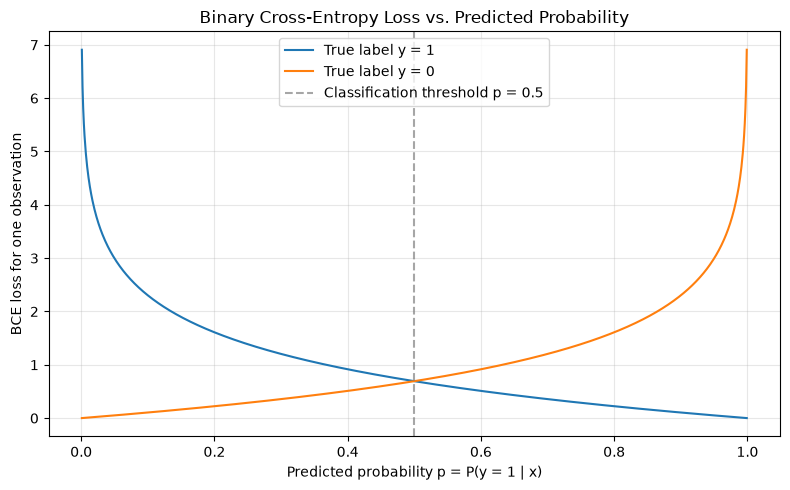

In [86]:
probabilities = np.linspace(
    0.001,
    0.999,
    1000
)

bce_when_y_is_1 = -np.log(
    probabilities
)

bce_when_y_is_0 = -np.log(
    1 - probabilities
)

plt.figure(figsize=(8, 5))

plt.plot(
    probabilities,
    bce_when_y_is_1,
    label="True label y = 1"
)

plt.plot(
    probabilities,
    bce_when_y_is_0,
    label="True label y = 0"
)

plt.axvline(
    0.5,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Classification threshold p = 0.5"
)

plt.xlabel(
    "Predicted probability p = P(y = 1 | x)"
)

plt.ylabel(
    "BCE loss for one observation"
)

plt.title(
    "Binary Cross-Entropy Loss vs. "
    "Predicted Probability"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
comparison_table = (
    pd.DataFrame([
        perceptron_results,
        logistic_results
    ])
    .set_index("Model")
)

display(
    comparison_table
    .round(4)
    .style
    .highlight_max(axis=0)
)

,Accuracy,Precision,Recall,F1
Model,,,,
Perceptron,0.689500,0.703500,0.790600,0.744500
Logistic Regression,0.774500,0.792900,0.820000,0.806200


In [89]:
metric_improvement = (
    comparison_table.loc[
        "Logistic Regression"
    ]
    - comparison_table.loc[
        "Perceptron"
    ]
)

print(
    "Logistic Regression improvement:"
)

print(
    metric_improvement.round(4)
)

Logistic Regression improvement:
Accuracy     0.0849
Precision    0.0894
Recall       0.0294
F1           0.0617
dtype: float64


## Discussion and Conclusion

### Discussion

Both models were evaluated on the same held-out test set using all
54 standardized features. The Perceptron achieved an accuracy of
0.6895, precision of 0.7035, recall of 0.7906, and F1-score of
0.7445. Logistic Regression achieved an accuracy of 0.7745,
precision of 0.7929, recall of 0.8200, and F1-score of 0.8062.
Both models exceeded the majority-class accuracy baseline of
approximately 0.5722, but Logistic Regression performed better on
all four reported metrics.

Relative to the Perceptron, Logistic Regression improved accuracy
by 0.0849, precision by 0.0894, recall by 0.0294, and F1-score by
0.0617. Its confusion matrix also showed fewer false positives
(12,136 versus 18,880) and fewer false negatives (10,199 versus
11,867). Overall, Logistic Regression made 22,335 test errors,
whereas the Perceptron made 30,747, a reduction of 8,412 errors in
this experiment.

The difference is consistent with the two models' training
objectives. The Perceptron makes a hard class decision and updates
its parameters only after a misclassification. It did not reach zero
updates within the ten training epochs, indicating that the training
observations were not easily separated by its learned linear boundary
under this setup. Logistic Regression instead optimizes a smooth BCE
objective and uses the magnitude of the probability error from every
training observation. It also provides probabilities rather than
only hard class predictions.

The final Logistic Regression training BCE was 0.475897, while its
test BCE was 0.478160. The small difference indicates that training
and test cross-entropy were similar for this particular split,
although it does not by itself establish generalization to other
samples. The theoretical BCE plot also demonstrates that confident
correct predictions receive a small loss, whereas confident incorrect
predictions receive a much larger penalty.

The two-feature visualization models showed the same overall pattern:
Logistic Regression obtained an accuracy of 0.7429, compared with
0.7082 for the Perceptron. The scatterplots show substantial overlap
between the two cover types when only Elevation and Horizontal
Distance to Roadways are used. Their straight decision boundaries
therefore cannot perfectly separate the observations. These
two-dimensional results should not be confused with the final
54-feature metrics because the visualization models were trained
separately using only two features.


### Conclusion

In this experiment, Logistic Regression was the stronger of the two
linear classifiers. It achieved better accuracy, precision, recall,
and F1-score, produced fewer false positives and false negatives, and
provided meaningful probability estimates with a test BCE of
0.478160. This does not imply that Logistic Regression will always
outperform a Perceptron, but it was more effective for the selected
cover types, preprocessing procedure, data split, and hyperparameters
used here.

Future work could evaluate the models with cross-validation, tune
their optimization parameters using a validation set, examine
regularization, extend the task to all seven cover types, and compare
the linear classifiers with nonlinear models capable of representing
more complex decision boundaries.